In [10]:
# CELL 1 — Kaggle Setup & Data Download

# Step 1: Upload your kaggle.json
from google.colab import files
files.upload()  # upload kaggle.json when prompted

# Step 2: Setup Kaggle credentials
import os
os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 600)

# Step 3: Install Kaggle
!pip install kaggle -q

# Step 4: Download Olist dataset
!kaggle datasets download -d olistbr/brazilian-ecommerce --unzip -p /content/olist

print("✅ Done! Files downloaded:")
os.listdir('/content/olist')

Saving kaggle.json to kaggle (1).json
Dataset URL: https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce
License(s): CC-BY-NC-SA-4.0
100% 42.6M/42.6M [00:00<00:00, 123MB/s]

✅ Done! Files downloaded:


['olist_customers_dataset.csv',
 'product_category_name_translation.csv',
 'olist_products_dataset.csv',
 'olist_orders_dataset.csv',
 'olist_order_payments_dataset.csv',
 'olist_order_items_dataset.csv',
 'olist_geolocation_dataset.csv',
 'olist_sellers_dataset.csv',
 'olist_order_reviews_dataset.csv']

In [11]:
# CELL 2 — Load & Merge All Tables

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

path = '/content/olist/'

# Load all tables
orders       = pd.read_csv(path + 'olist_orders_dataset.csv')
customers    = pd.read_csv(path + 'olist_customers_dataset.csv')
order_items  = pd.read_csv(path + 'olist_order_items_dataset.csv')
payments     = pd.read_csv(path + 'olist_order_payments_dataset.csv')
reviews      = pd.read_csv(path + 'olist_order_reviews_dataset.csv')
products     = pd.read_csv(path + 'olist_products_dataset.csv')
sellers      = pd.read_csv(path + 'olist_sellers_dataset.csv')
geo          = pd.read_csv(path + 'olist_geolocation_dataset.csv')
translation  = pd.read_csv(path + 'product_category_name_translation.csv')

# Merge step by step
df = orders.merge(customers,   on='customer_id',   how='left')
df = df.merge(order_items,     on='order_id',      how='left')
df = df.merge(payments,        on='order_id',      how='left')
df = df.merge(reviews,         on='order_id',      how='left')
df = df.merge(products,        on='product_id',    how='left')
df = df.merge(sellers,         on='seller_id',     how='left')
df = df.merge(translation,     on='product_category_name', how='left')

print(f"✅ Master DataFrame shape: {df.shape}")
print(f"📋 Columns: {df.columns.tolist()}")
print(f"\n🔍 Quick peek:")
df.head(3)

✅ Master DataFrame shape: (119143, 40)
📋 Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value', 'review_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'seller_zip_code_prefix', 'seller_city', 'seller_state', 'product_category_name_english']

🔍 Quick peek:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,268.0,4.0,500.0,19.0,8.0,13.0,9350.0,maua,SP,housewares
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,268.0,4.0,500.0,19.0,8.0,13.0,9350.0,maua,SP,housewares
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,268.0,4.0,500.0,19.0,8.0,13.0,9350.0,maua,SP,housewares


In [12]:
# CELL 3 — First Look at the Data

print("=" * 60)
print("📐 SHAPE:", df.shape)
print("=" * 60)

print("\n📋 COLUMN DATA TYPES:")
print(df.dtypes)

print("\n🔍 MISSING VALUES (count + %):")
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2)
})
print(missing[missing['Missing Count'] > 0].sort_values('Missing %', ascending=False))

print("\n📊 DUPLICATES:")
print(f"  Duplicate rows: {df.duplicated().sum()}")
print(f"  Duplicate order_ids: {df['order_id'].duplicated().sum()}")

print("\n📈 NUMERICAL SUMMARY:")
df.describe().T

📐 SHAPE: (119143, 40)

📋 COLUMN DATA TYPES:
order_id                          object
customer_id                       object
order_status                      object
order_purchase_timestamp          object
order_approved_at                 object
order_delivered_carrier_date      object
order_delivered_customer_date     object
order_estimated_delivery_date     object
customer_unique_id                object
customer_zip_code_prefix           int64
customer_city                     object
customer_state                    object
order_item_id                    float64
product_id                        object
seller_id                         object
shipping_limit_date               object
price                            float64
freight_value                    float64
payment_sequential               float64
payment_type                      object
payment_installments             float64
payment_value                    float64
review_id                         object
review_score 

,count,mean,std,min,25%,50%,75%,max
customer_zip_code_prefix,119143.0,35033.451298,29823.198969,1003.00,11250.00,24240.00,58475.00,99990.00
order_item_id,118310.0,1.196543,0.699489,1.00,1.00,1.00,1.00,21.00
price,118310.0,120.646603,184.109691,0.85,39.90,74.90,134.90,6735.00
freight_value,118310.0,20.032387,15.836850,0.00,13.08,16.28,21.18,409.68
payment_sequential,119140.0,1.094737,0.730141,1.00,1.00,1.00,1.00,29.00
payment_installments,119140.0,2.941246,2.777848,0.00,1.00,2.00,4.00,24.00
payment_value,119140.0,172.735135,267.776077,0.00,60.85,108.16,189.24,13664.08
review_score,118146.0,4.015582,1.400436,1.00,4.00,5.00,5.00,5.00
product_name_lenght,116601.0,48.767498,10.033540,5.00,42.00,52.00,57.00,76.00
product_description_lenght,116601.0,785.967822,652.584121,4.00,346.00,600.00,983.00,3992.00


In [13]:
# CELL 4 — Data Cleaning

df_clean = df.copy()

# ── 1. FIX DATE COLUMNS ──────────────────────────────────────
date_cols = [
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date', 'shipping_limit_date',
    'review_creation_date', 'review_answer_timestamp'
]
for col in date_cols:
    df_clean[col] = pd.to_datetime(df_clean[col], errors='coerce')

print("✅ Dates fixed")

# ── 2. DROP HIGH MISSING COLUMNS ─────────────────────────────
df_clean.drop(columns=['review_comment_title', 'review_comment_message'], inplace=True)
print("✅ Dropped high-missing text columns (88%, 58%)")

# ── 3. FILL MISSING — PRODUCT DIMENSIONS (median) ────────────
product_dim_cols = [
    'product_weight_g', 'product_length_cm',
    'product_height_cm', 'product_width_cm',
    'product_name_lenght', 'product_description_lenght', 'product_photos_qty'
]
for col in product_dim_cols:
    df_clean[col].fillna(df_clean[col].median(), inplace=True)

print("✅ Product dimensions filled with median")

# ── 4. FILL MISSING — CATEGORY ───────────────────────────────
df_clean['product_category_name_english'].fillna('unknown', inplace=True)
df_clean['product_category_name'].fillna('unknown', inplace=True)
print("✅ Product category nulls → 'unknown'")

# ── 5. DROP ROWS — CRITICAL NULLS ────────────────────────────
before = len(df_clean)
df_clean.dropna(subset=['price', 'seller_id', 'product_id', 'review_score', 'payment_value'], inplace=True)
after = len(df_clean)
print(f"✅ Dropped {before - after} rows with missing critical fields")

# ── 6. FIX DATA TYPES ────────────────────────────────────────
df_clean['order_item_id']        = df_clean['order_item_id'].astype(int)
df_clean['payment_installments'] = df_clean['payment_installments'].astype(int)
df_clean['review_score']         = df_clean['review_score'].astype(int)
print("✅ Fixed int dtypes")

# ── 7. REMOVE PRICE OUTLIERS (IQR method) ────────────────────
Q1 = df_clean['price'].quantile(0.25)
Q3 = df_clean['price'].quantile(0.75)
IQR = Q3 - Q1
df_clean = df_clean[
    (df_clean['price'] >= Q1 - 3 * IQR) &
    (df_clean['price'] <= Q3 + 3 * IQR)
]
print(f"✅ Outliers removed. Clean shape: {df_clean.shape}")

# ── 8. RENAME TYPO COLUMNS ───────────────────────────────────
df_clean.rename(columns={
    'product_name_lenght': 'product_name_length',
    'product_description_lenght': 'product_description_length'
}, inplace=True)
print("✅ Fixed typos in column names")

# ── FINAL CHECK ──────────────────────────────────────────────
print("\n📋 Remaining nulls:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])
print(f"\n✅ FINAL CLEAN SHAPE: {df_clean.shape}")

✅ Dates fixed
✅ Dropped high-missing text columns (88%, 58%)
✅ Product dimensions filled with median
✅ Product category nulls → 'unknown'
✅ Dropped 1814 rows with missing critical fields
✅ Fixed int dtypes
✅ Outliers removed. Clean shape: (113079, 38)
✅ Fixed typos in column names

📋 Remaining nulls:
order_approved_at                  15
order_delivered_carrier_date     1128
order_delivered_customer_date    2311
dtype: int64

✅ FINAL CLEAN SHAPE: (113079, 38)


In [14]:
# CELL 5 — Feature Engineering

# ── 1. DELIVERY TIME (days) ───────────────────────────────────
df_clean['delivery_days'] = (
    df_clean['order_delivered_customer_date'] -
    df_clean['order_purchase_timestamp']
).dt.days

# ── 2. ESTIMATED vs ACTUAL DELIVERY (delay in days) ──────────
df_clean['delivery_delay_days'] = (
    df_clean['order_delivered_customer_date'] -
    df_clean['order_estimated_delivery_date']
).dt.days
# Negative = early, Positive = late

# ── 3. IS LATE? ───────────────────────────────────────────────
df_clean['is_late'] = (df_clean['delivery_delay_days'] > 0).astype(int)

# ── 4. ORDER APPROVAL TIME (hours) ───────────────────────────
df_clean['approval_time_hours'] = (
    df_clean['order_approved_at'] -
    df_clean['order_purchase_timestamp']
).dt.total_seconds() / 3600

# ── 5. TOTAL ORDER VALUE ──────────────────────────────────────
df_clean['total_order_value'] = df_clean['price'] + df_clean['freight_value']

# ── 6. FREIGHT RATIO (freight % of total) ────────────────────
df_clean['freight_ratio'] = (
    df_clean['freight_value'] / df_clean['total_order_value']
).round(4)

# ── 7. TIME FEATURES ──────────────────────────────────────────
df_clean['purchase_year']    = df_clean['order_purchase_timestamp'].dt.year
df_clean['purchase_month']   = df_clean['order_purchase_timestamp'].dt.month
df_clean['purchase_dayofweek'] = df_clean['order_purchase_timestamp'].dt.dayofweek  # 0=Mon
df_clean['purchase_hour']    = df_clean['order_purchase_timestamp'].dt.hour

# ── 8. IS WEEKEND? ────────────────────────────────────────────
df_clean['is_weekend'] = (df_clean['purchase_dayofweek'] >= 5).astype(int)

# ── 9. REVIEW SENTIMENT BUCKET ───────────────────────────────
df_clean['review_sentiment'] = pd.cut(
    df_clean['review_score'],
    bins=[0, 2, 3, 5],
    labels=['negative', 'neutral', 'positive']
)

# ── 10. PRODUCT VOLUME (cm³) ─────────────────────────────────
df_clean['product_volume_cm3'] = (
    df_clean['product_length_cm'] *
    df_clean['product_height_cm'] *
    df_clean['product_width_cm']
)

# ── 11. CUSTOMER REGION (from state) ─────────────────────────
region_map = {
    'SP': 'Southeast', 'RJ': 'Southeast', 'MG': 'Southeast', 'ES': 'Southeast',
    'RS': 'South',     'SC': 'South',     'PR': 'South',
    'BA': 'Northeast', 'PE': 'Northeast', 'CE': 'Northeast', 'MA': 'Northeast',
    'PA': 'North',     'AM': 'North',     'RO': 'North',
    'GO': 'Midwest',   'MT': 'Midwest',   'MS': 'Midwest',   'DF': 'Midwest'
}
df_clean['customer_region'] = df_clean['customer_state'].map(region_map).fillna('Other')

# ── CHECK ─────────────────────────────────────────────────────
print(f"✅ Features engineered. New shape: {df_clean.shape}")
print(f"\n🆕 New columns added:")
new_cols = ['delivery_days', 'delivery_delay_days', 'is_late', 'approval_time_hours',
            'total_order_value', 'freight_ratio', 'purchase_year', 'purchase_month',
            'purchase_dayofweek', 'purchase_hour', 'is_weekend', 'review_sentiment',
            'product_volume_cm3', 'customer_region']
print(new_cols)

print("\n📊 Sample new features:")
df_clean[new_cols].describe().T[['mean','min','max']]

✅ Features engineered. New shape: (113079, 52)

🆕 New columns added:
['delivery_days', 'delivery_delay_days', 'is_late', 'approval_time_hours', 'total_order_value', 'freight_ratio', 'purchase_year', 'purchase_month', 'purchase_dayofweek', 'purchase_hour', 'is_weekend', 'review_sentiment', 'product_volume_cm3', 'customer_region']

📊 Sample new features:


,mean,min,max
delivery_days,11.904774,0.00,208.000000
delivery_delay_days,-12.086487,-147.00,188.000000
is_late,0.062107,0.00,1.000000
approval_time_hours,10.418834,0.00,1450.866389
total_order_value,112.986240,6.08,660.390000
freight_ratio,0.219802,0.00,0.963300
purchase_year,2017.537438,2016.00,2018.000000
purchase_month,6.027821,1.00,12.000000
purchase_dayofweek,2.746938,0.00,6.000000
purchase_hour,14.755622,0.00,23.000000


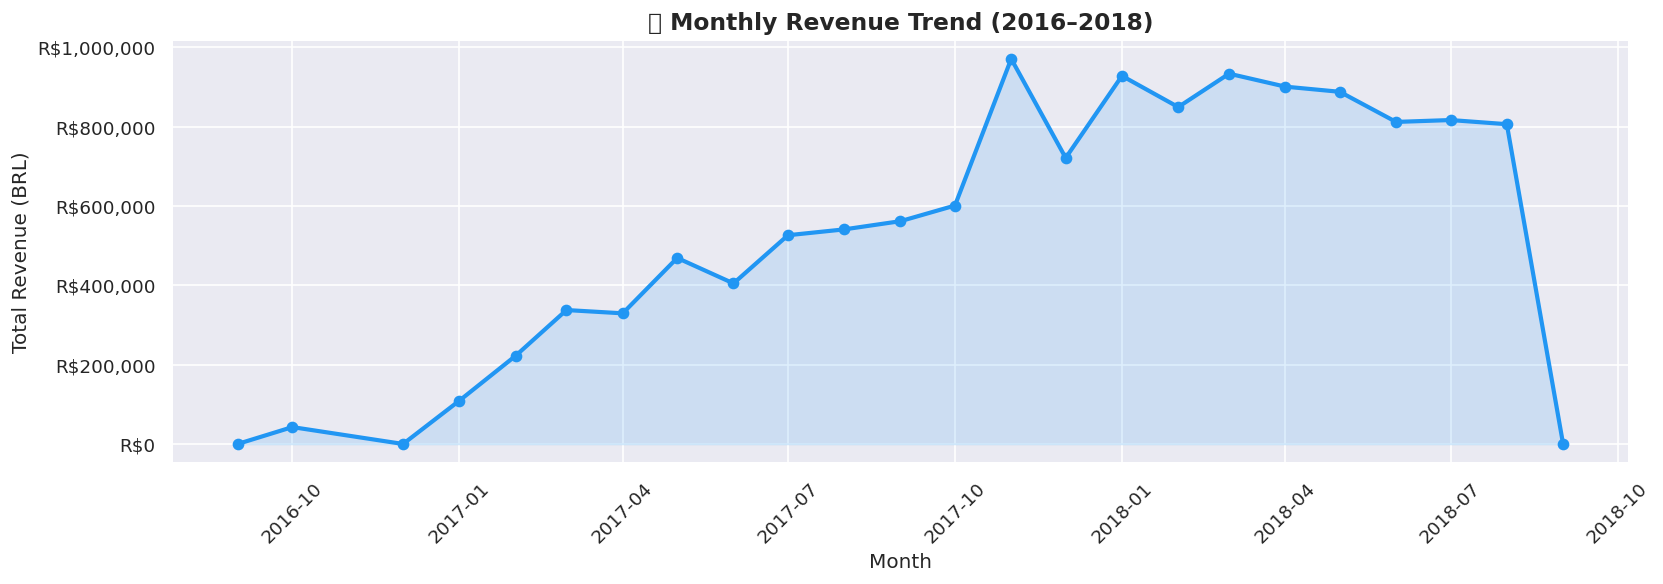

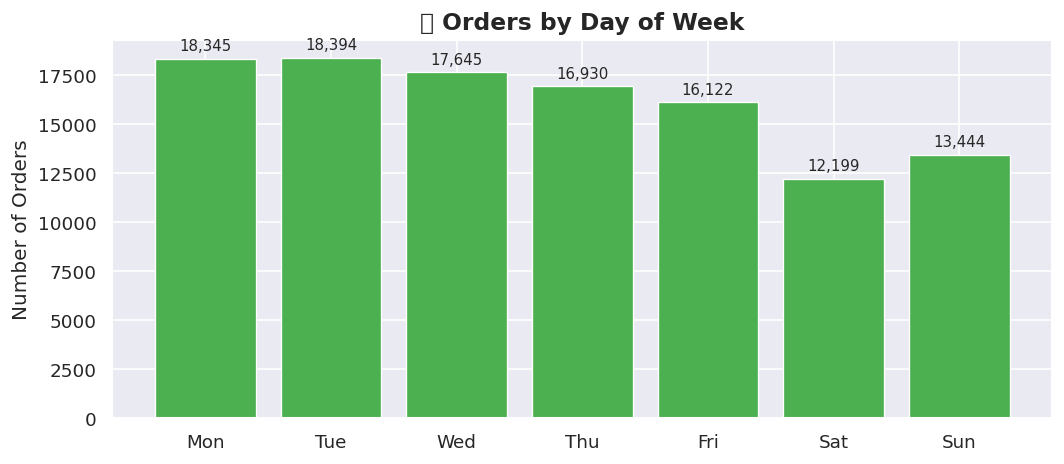

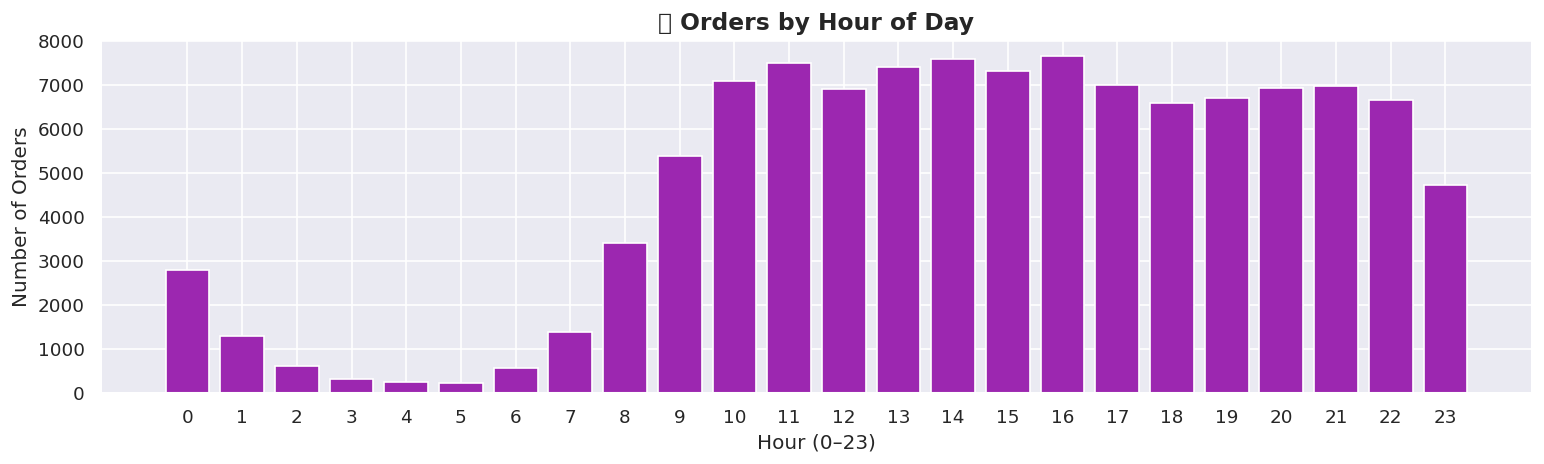

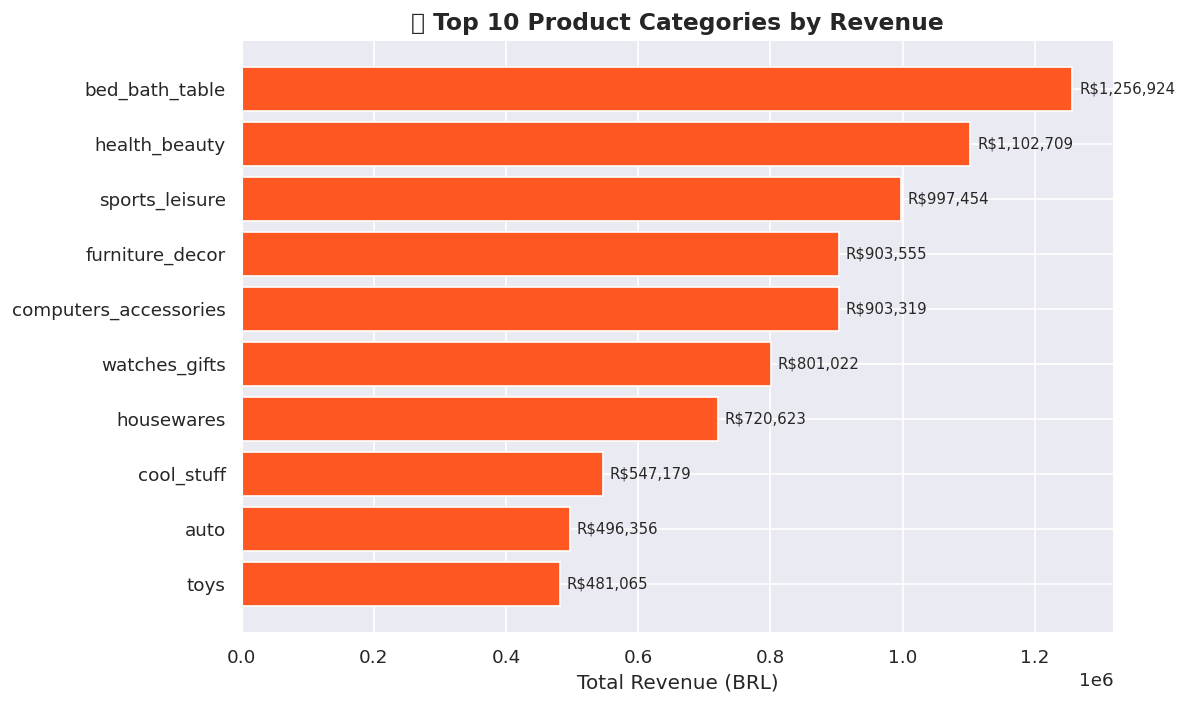

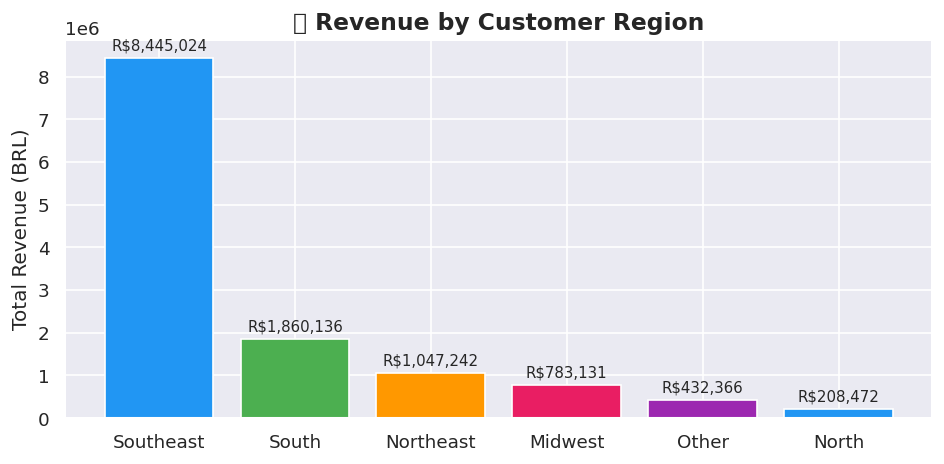

✅ Cell 6 done — Sales & Revenue charts complete!


In [15]:
# CELL 6 — EDA + Visualizations (Part 1: Sales & Revenue)

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Style
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

# ── 1. MONTHLY REVENUE TREND ──────────────────────────────────
monthly_revenue = (
    df_clean.groupby(['purchase_year', 'purchase_month'])['total_order_value']
    .sum()
    .reset_index()
)
monthly_revenue['period'] = pd.to_datetime(
    monthly_revenue['purchase_year'].astype(str) + '-' +
    monthly_revenue['purchase_month'].astype(str)
)
monthly_revenue = monthly_revenue.sort_values('period')

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_revenue['period'], monthly_revenue['total_order_value'],
        marker='o', linewidth=2.5, color='#2196F3')
ax.fill_between(monthly_revenue['period'], monthly_revenue['total_order_value'],
                alpha=0.15, color='#2196F3')
ax.set_title('📈 Monthly Revenue Trend (2016–2018)', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Revenue (BRL)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x:,.0f}'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ── 2. ORDERS BY DAY OF WEEK ──────────────────────────────────
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
orders_by_day = df_clean.groupby('purchase_dayofweek')['order_id'].count()

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(day_labels, orders_by_day.values, color='#4CAF50', edgecolor='white', linewidth=0.8)
ax.bar_label(bars, fmt='{:,.0f}', padding=3, fontsize=9)
ax.set_title('🗓️ Orders by Day of Week', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Orders')
plt.tight_layout()
plt.show()

# ── 3. ORDERS BY HOUR ─────────────────────────────────────────
orders_by_hour = df_clean.groupby('purchase_hour')['order_id'].count()

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(orders_by_hour.index, orders_by_hour.values, color='#9C27B0', edgecolor='white')
ax.set_title('⏰ Orders by Hour of Day', fontsize=14, fontweight='bold')
ax.set_xlabel('Hour (0–23)')
ax.set_ylabel('Number of Orders')
ax.set_xticks(range(24))
plt.tight_layout()
plt.show()

# ── 4. TOP 10 PRODUCT CATEGORIES BY REVENUE ──────────────────
cat_revenue = (
    df_clean.groupby('product_category_name_english')['total_order_value']
    .sum()
    .sort_values(ascending=True)
    .tail(10)
)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(cat_revenue.index, cat_revenue.values, color='#FF5722', edgecolor='white')
ax.bar_label(bars, fmt='R${:,.0f}', padding=4, fontsize=9)
ax.set_title('🏆 Top 10 Product Categories by Revenue', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Revenue (BRL)')
plt.tight_layout()
plt.show()

# ── 5. REVENUE BY CUSTOMER REGION ────────────────────────────
region_rev = (
    df_clean.groupby('customer_region')['total_order_value']
    .sum()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(region_rev.index, region_rev.values,
              color=['#2196F3','#4CAF50','#FF9800','#E91E63','#9C27B0'],
              edgecolor='white')
ax.bar_label(bars, fmt='R${:,.0f}', padding=3, fontsize=9)
ax.set_title('🗺️ Revenue by Customer Region', fontsize=14, fontweight='bold')
ax.set_ylabel('Total Revenue (BRL)')
plt.tight_layout()
plt.show()

print("✅ Cell 6 done — Sales & Revenue charts complete!")

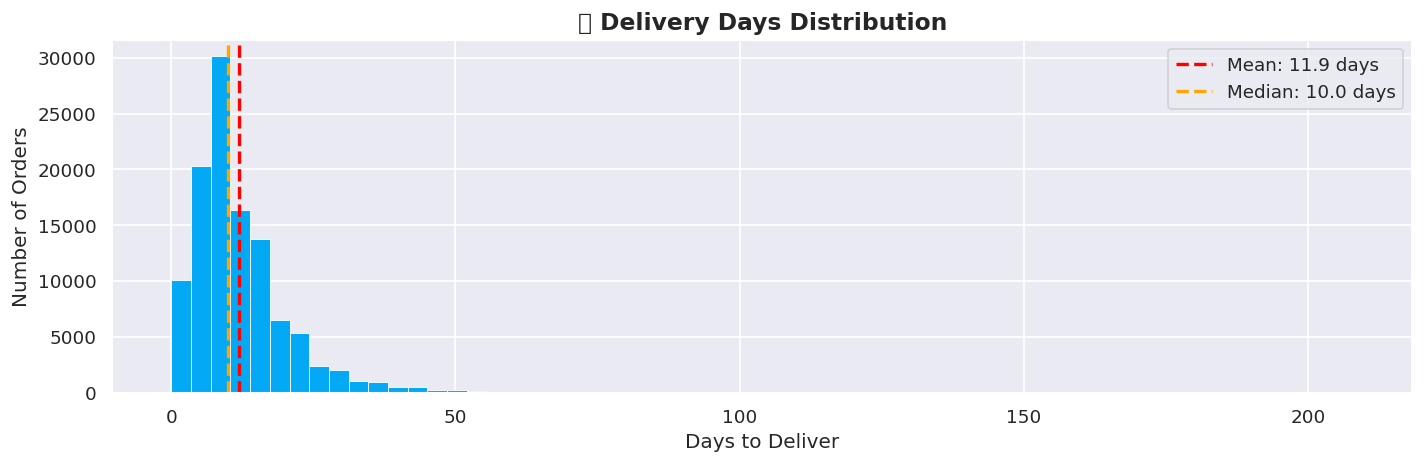

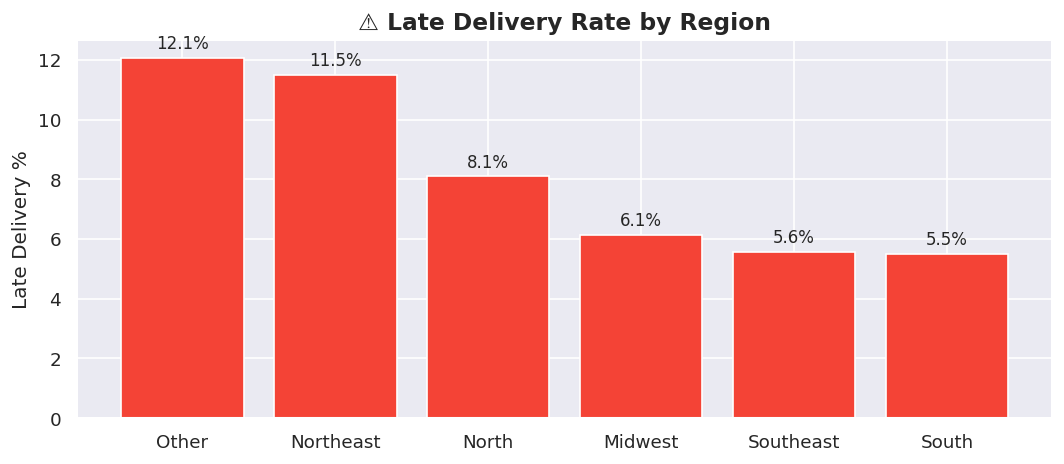

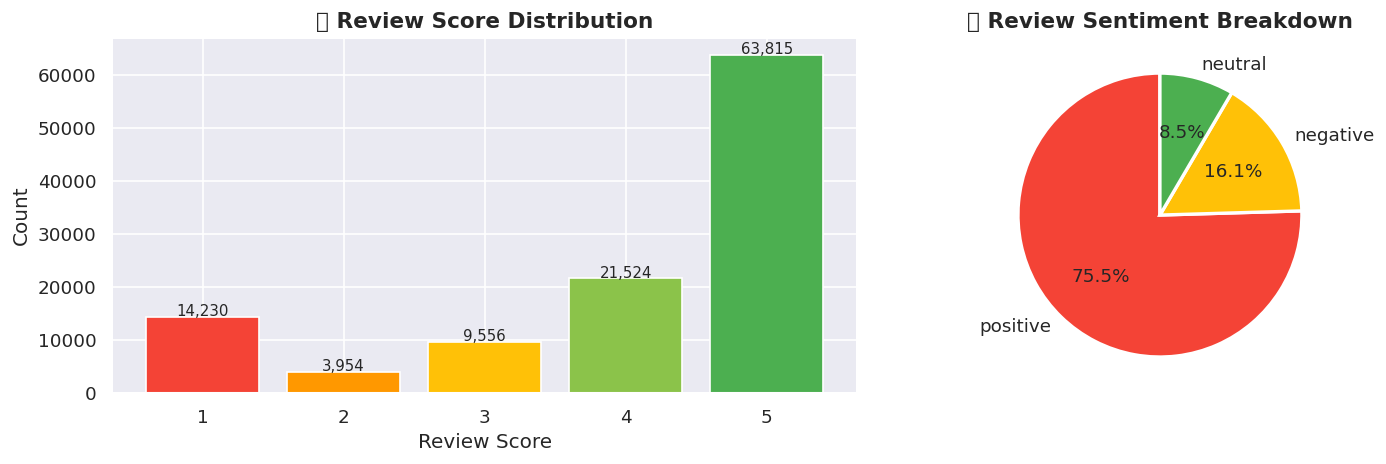

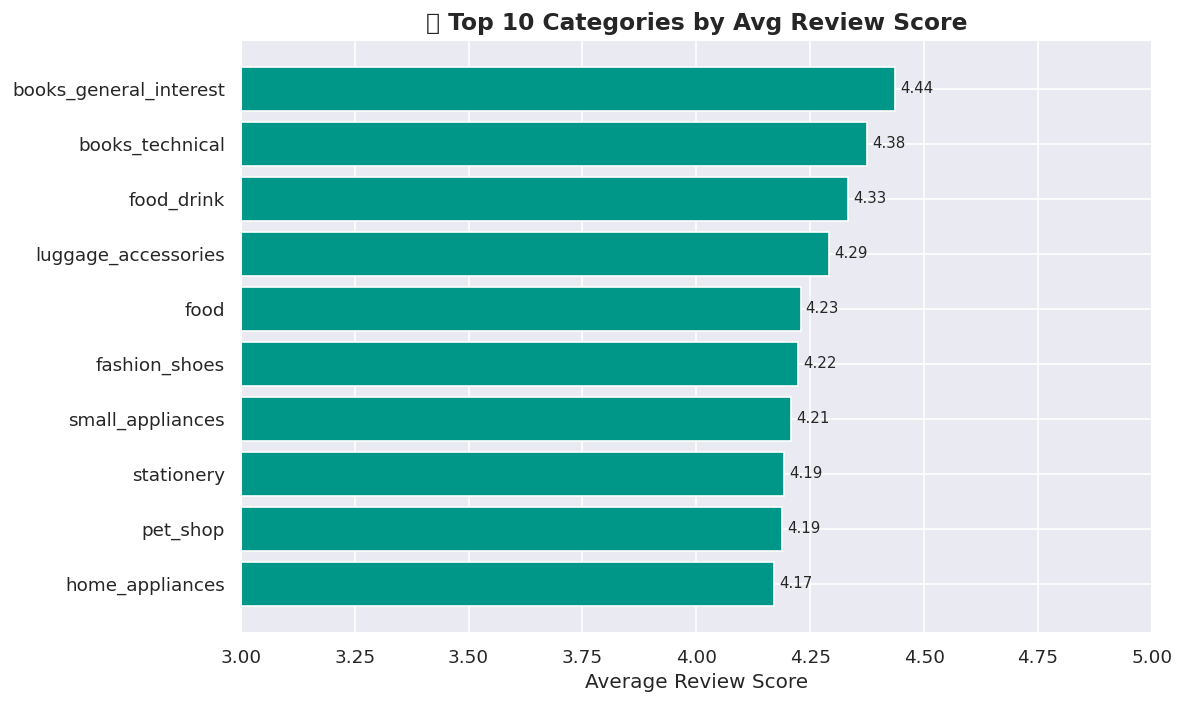

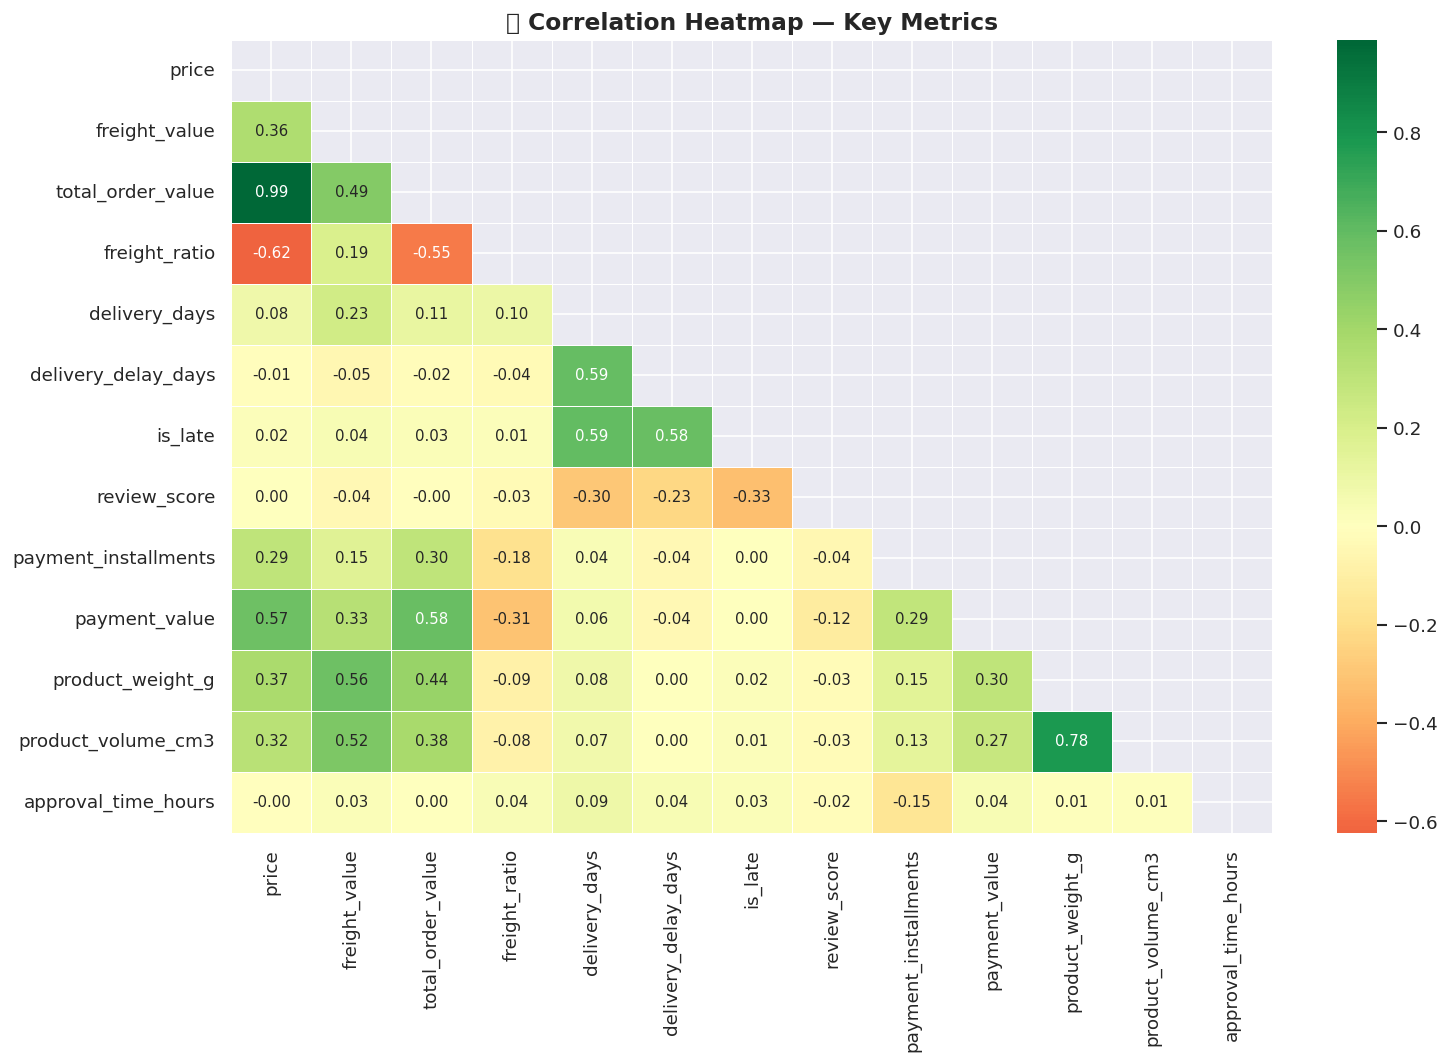

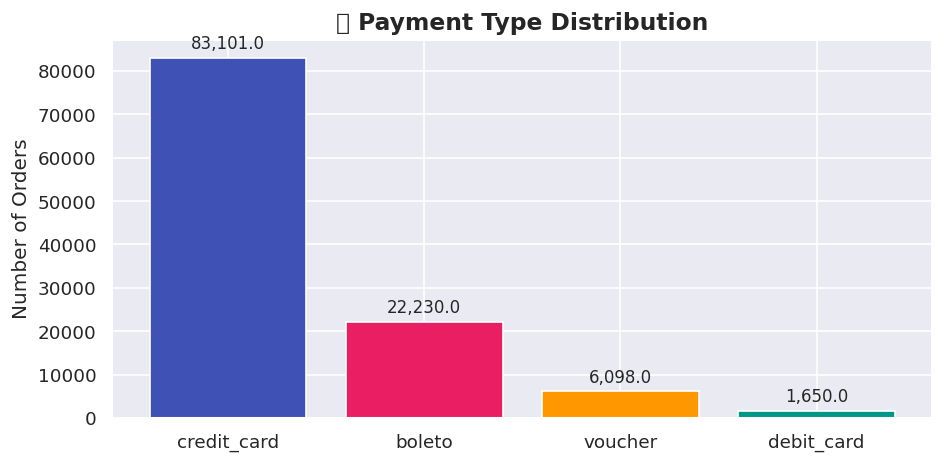

✅ Cell 7 done — Delivery, Reviews & Correlations complete!


In [16]:
# CELL 7 — EDA Part 2: Delivery, Reviews & Correlations

# ── 1. DELIVERY DAYS DISTRIBUTION ────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
delivery_data = df_clean['delivery_days'].dropna()
ax.hist(delivery_data, bins=60, color='#03A9F4', edgecolor='white', linewidth=0.5)
ax.axvline(delivery_data.mean(), color='red', linestyle='--', linewidth=2,
           label=f'Mean: {delivery_data.mean():.1f} days')
ax.axvline(delivery_data.median(), color='orange', linestyle='--', linewidth=2,
           label=f'Median: {delivery_data.median():.1f} days')
ax.set_title('🚚 Delivery Days Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Days to Deliver')
ax.set_ylabel('Number of Orders')
ax.legend()
plt.tight_layout()
plt.show()

# ── 2. LATE vs ON-TIME BY REGION ─────────────────────────────
late_by_region = (
    df_clean.groupby('customer_region')['is_late']
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .reset_index()
)
late_by_region.columns = ['Region', 'Late %']

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(late_by_region['Region'], late_by_region['Late %'],
              color='#F44336', edgecolor='white')
ax.bar_label(bars, fmt='{:.1f}%', padding=3, fontsize=10)
ax.set_title('⚠️ Late Delivery Rate by Region', fontsize=14, fontweight='bold')
ax.set_ylabel('Late Delivery %')
plt.tight_layout()
plt.show()

# ── 3. REVIEW SCORE DISTRIBUTION ─────────────────────────────
review_counts = df_clean['review_score'].value_counts().sort_index()
colors = ['#F44336','#FF9800','#FFC107','#8BC34A','#4CAF50']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Bar
axes[0].bar(review_counts.index, review_counts.values, color=colors, edgecolor='white')
axes[0].set_title('⭐ Review Score Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Review Score')
axes[0].set_ylabel('Count')
for i, (score, count) in enumerate(zip(review_counts.index, review_counts.values)):
    axes[0].text(score, count + 200, f'{count:,}', ha='center', fontsize=9)

# Pie
sentiment_counts = df_clean['review_sentiment'].value_counts()
axes[1].pie(sentiment_counts.values,
            labels=sentiment_counts.index,
            autopct='%1.1f%%',
            colors=['#F44336','#FFC107','#4CAF50'],
            startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('💬 Review Sentiment Breakdown', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 4. AVG REVIEW SCORE BY CATEGORY (Top 10) ─────────────────
cat_review = (
    df_clean.groupby('product_category_name_english')['review_score']
    .agg(['mean', 'count'])
    .query('count >= 200')
    .sort_values('mean', ascending=True)
    .tail(10)
)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(cat_review.index, cat_review['mean'],
               color='#009688', edgecolor='white')
ax.bar_label(bars, fmt='{:.2f}', padding=3, fontsize=9)
ax.set_xlim(3, 5)
ax.set_title('⭐ Top 10 Categories by Avg Review Score', fontsize=14, fontweight='bold')
ax.set_xlabel('Average Review Score')
plt.tight_layout()
plt.show()

# ── 5. CORRELATION HEATMAP ────────────────────────────────────
corr_cols = [
    'price', 'freight_value', 'total_order_value', 'freight_ratio',
    'delivery_days', 'delivery_delay_days', 'is_late',
    'review_score', 'payment_installments', 'payment_value',
    'product_weight_g', 'product_volume_cm3', 'approval_time_hours'
]

fig, ax = plt.subplots(figsize=(13, 9))
corr_matrix = df_clean[corr_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5,
            annot_kws={'size': 9}, ax=ax)
ax.set_title('🔥 Correlation Heatmap — Key Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 6. PAYMENT TYPE BREAKDOWN ─────────────────────────────────
pay_counts = df_clean['payment_type'].value_counts()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(pay_counts.index, pay_counts.values,
              color=['#3F51B5','#E91E63','#FF9800','#009688'],
              edgecolor='white')
ax.bar_label(bars, fmt='{:,}', padding=3, fontsize=10)
ax.set_title('💳 Payment Type Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Orders')
plt.tight_layout()
plt.show()

print("✅ Cell 7 done — Delivery, Reviews & Correlations complete!")

📊 RFM Segment Summary:
                     Customers  Avg_Recency  Avg_Frequency  Avg_Monetary
Segment                                                                 
Loyal Customers          26600        149.3            1.0         118.1
At Risk                  21693        400.3            1.0         144.4
New Customers            14648         96.1            1.0         135.6
Cant Lose Them            8461        400.5            1.0         194.5
Hibernating               7510        317.3            1.0          55.0
Champions                 6309         96.6            1.2         251.2
Potential Loyalists       4225        226.4            1.0         186.6
Lost                      1558        480.7            1.0          54.8


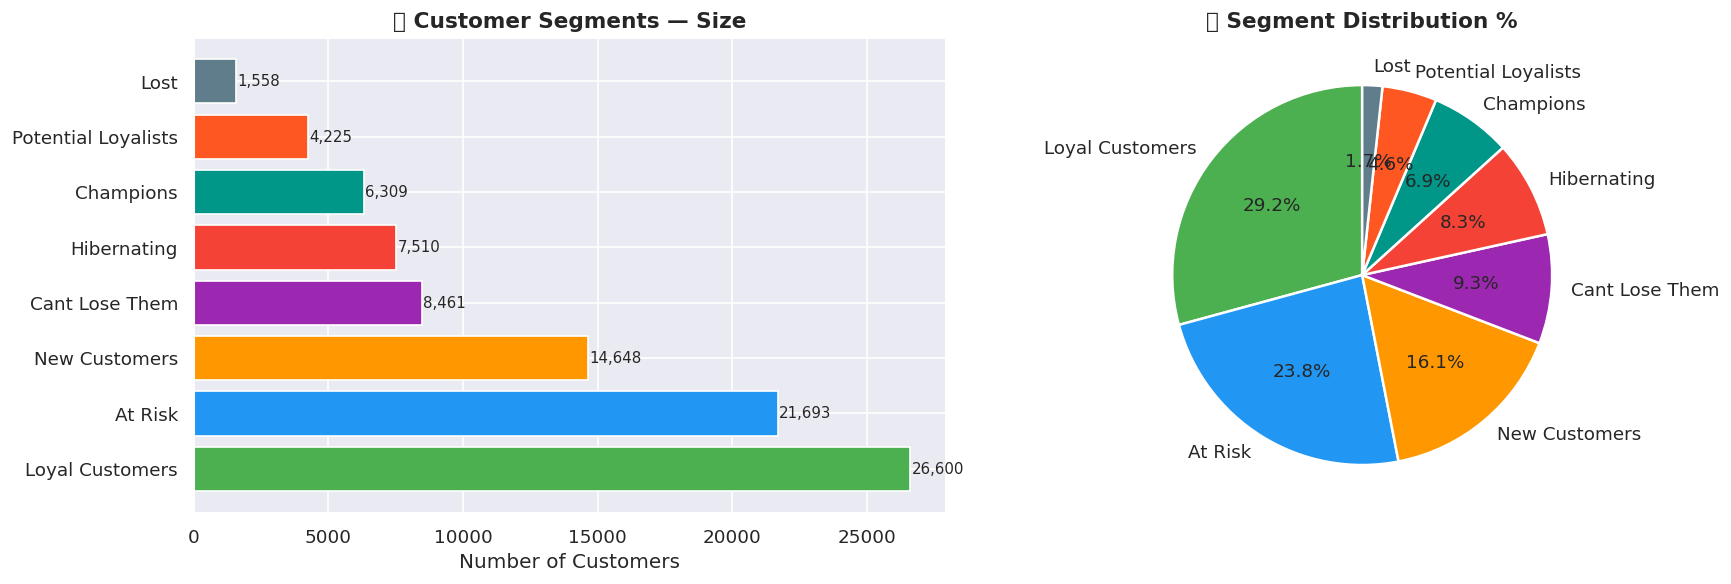

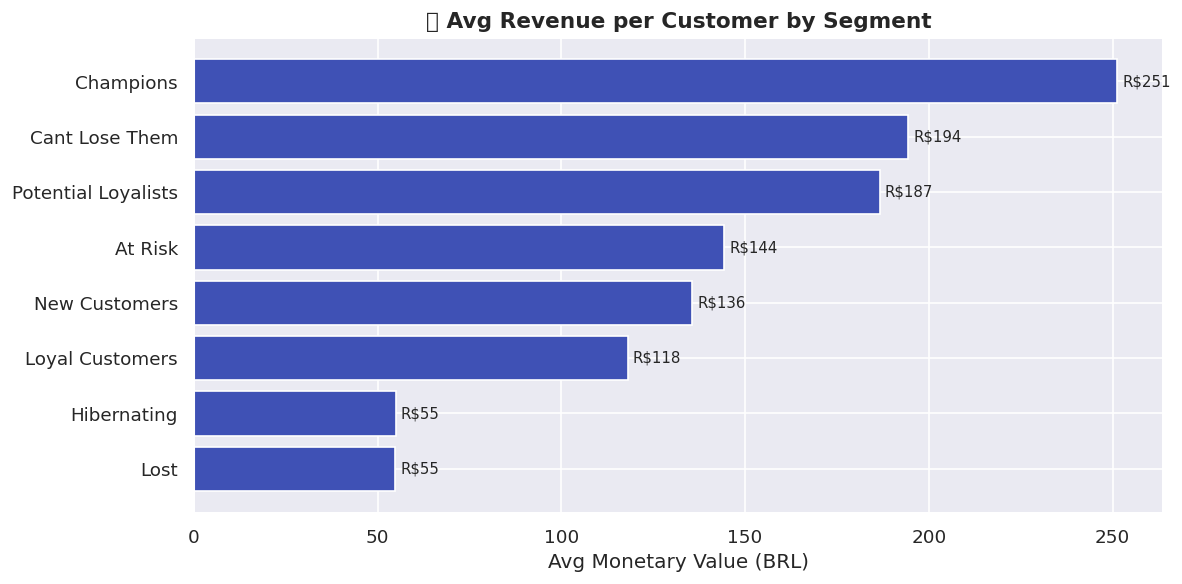

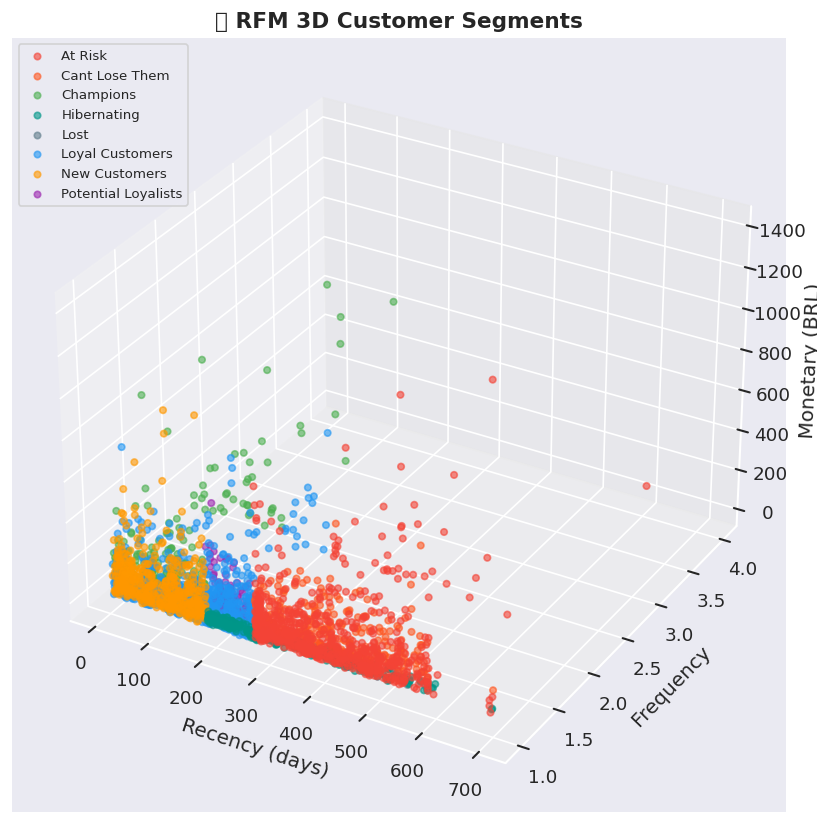

✅ Cell 8 done — RFM Analysis complete!

📋 RFM Table Preview:


,customer_unique_id,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,RFM_Total,Segment
0,0000366f3b9a7992bf8c76cfdf3221e2,116,1,141.90,4,1,4,414,9,New Customers
1,0000b849f77a49e4a4ce2b2a4ca5be3f,119,1,27.19,4,1,1,411,6,New Customers
2,0000f46a3911fa3c0805444483337064,542,1,86.22,1,1,3,113,5,Cant Lose Them
3,0000f6ccb0745a6a4b88665a16c9f078,326,1,43.62,2,1,1,211,4,Hibernating
4,0004aac84e0df4da2b147fca70cf8255,293,1,196.89,2,1,4,214,7,Cant Lose Them
5,0004bd2a26a76fe21f786e4fbd80607f,151,1,166.98,4,1,4,414,9,New Customers
6,00050ab1314c0e55a6ca13cf7181fecf,136,1,35.38,4,1,1,411,6,New Customers
7,00053a61a98854899e70ed204dd4bafe,187,1,419.18,3,1,5,315,9,Potential Loyalists
8,0005e1862207bf6ccc02e4228effd9a0,548,1,150.12,1,1,4,114,6,Cant Lose Them
9,0005ef4cd20d2893f0d9fbd94d3c0d97,175,1,129.76,4,1,4,414,9,New Customers


In [17]:
# CELL 8 — RFM Analysis (Recency, Frequency, Monetary)

# ── SETUP ─────────────────────────────────────────────────────
snapshot_date = df_clean['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

rfm = (
    df_clean.groupby('customer_unique_id')
    .agg(
        Recency   = ('order_purchase_timestamp', lambda x: (snapshot_date - x.max()).days),
        Frequency = ('order_id', 'nunique'),
        Monetary  = ('total_order_value', 'sum')
    )
    .reset_index()
)

# ── SCORING (1–5) ─────────────────────────────────────────────
rfm['R_score'] = pd.qcut(rfm['Recency'],   q=5, labels=[5,4,3,2,1]).astype(int)
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5]).astype(int)
rfm['M_score'] = pd.qcut(rfm['Monetary'],  q=5, labels=[1,2,3,4,5]).astype(int)

rfm['RFM_Score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)
rfm['RFM_Total'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']

# ── SEGMENT ───────────────────────────────────────────────────
def segment(row):
    r, f, m = row['R_score'], row['F_score'], row['M_score']
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r >= 3 and f <= 2 and m >= 3:
        return 'Potential Loyalists'
    elif r <= 2 and f >= 3:
        return 'At Risk'
    elif r <= 2 and f <= 2 and m >= 3:
        return 'Cant Lose Them'
    elif r == 1 and f == 1:
        return 'Lost'
    else:
        return 'Hibernating'

rfm['Segment'] = rfm.apply(segment, axis=1)

# ── PRINT SUMMARY ─────────────────────────────────────────────
print("📊 RFM Segment Summary:")
print(rfm.groupby('Segment').agg(
    Customers = ('customer_unique_id', 'count'),
    Avg_Recency   = ('Recency', 'mean'),
    Avg_Frequency = ('Frequency', 'mean'),
    Avg_Monetary  = ('Monetary', 'mean')
).round(1).sort_values('Customers', ascending=False))

# ── VIZ 1: SEGMENT SIZE ───────────────────────────────────────
seg_counts = rfm['Segment'].value_counts()
colors_seg = ['#4CAF50','#2196F3','#FF9800','#9C27B0','#F44336','#009688','#FF5722','#607D8B']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].barh(seg_counts.index, seg_counts.values, color=colors_seg, edgecolor='white')
for i, (val) in enumerate(seg_counts.values):
    axes[0].text(val + 50, i, f'{val:,}', va='center', fontsize=9)
axes[0].set_title('👥 Customer Segments — Size', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Customers')

axes[1].pie(seg_counts.values, labels=seg_counts.index,
            autopct='%1.1f%%', colors=colors_seg,
            startangle=90, wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[1].set_title('👥 Segment Distribution %', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── VIZ 2: AVG MONETARY BY SEGMENT ───────────────────────────
seg_monetary = rfm.groupby('Segment')['Monetary'].mean().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(seg_monetary.index, seg_monetary.values, color='#3F51B5', edgecolor='white')
ax.bar_label(bars, fmt='R${:,.0f}', padding=3, fontsize=9)
ax.set_title('💰 Avg Revenue per Customer by Segment', fontsize=13, fontweight='bold')
ax.set_xlabel('Avg Monetary Value (BRL)')
plt.tight_layout()
plt.show()

# ── VIZ 3: RFM 3D SCATTER ─────────────────────────────────────
from mpl_toolkits.mplot3d import Axes3D

seg_colors = {
    'Champions':'#4CAF50', 'Loyal Customers':'#2196F3',
    'New Customers':'#FF9800', 'Potential Loyalists':'#9C27B0',
    'At Risk':'#F44336', 'Cant Lose Them':'#FF5722',
    'Lost':'#607D8B', 'Hibernating':'#009688'
}

sample = rfm.sample(min(3000, len(rfm)), random_state=42)

fig = plt.figure(figsize=(12, 7))
ax = fig.add_subplot(111, projection='3d')
for seg, grp in sample.groupby('Segment'):
    ax.scatter(grp['Recency'], grp['Frequency'], grp['Monetary'],
               c=seg_colors.get(seg, 'gray'), label=seg, alpha=0.6, s=15)

ax.set_xlabel('Recency (days)')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary (BRL)')
ax.set_title('🌐 RFM 3D Customer Segments', fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

print("✅ Cell 8 done — RFM Analysis complete!")
print(f"\n📋 RFM Table Preview:")
rfm.head(10)

In [18]:
# CELL 9 — Business Insights & Recommendations

print("=" * 65)
print("       📊 OLIST E-COMMERCE — BUSINESS INSIGHTS REPORT")
print("=" * 65)

# ── INSIGHT 1: REVENUE GROWTH ─────────────────────────────────
rev_2017 = df_clean[df_clean['purchase_year'] == 2017]['total_order_value'].sum()
rev_2018 = df_clean[df_clean['purchase_year'] == 2018]['total_order_value'].sum()
growth   = ((rev_2018 - rev_2017) / rev_2017) * 100

print("\n📈 INSIGHT 1 — Revenue Growth")
print(f"   2017 Revenue : R${rev_2017:>12,.0f}")
print(f"   2018 Revenue : R${rev_2018:>12,.0f}")
print(f"   YoY Growth   : {growth:>+.1f}%")
print("   ✅ RECOMMENDATION: Scale marketing spend — strong growth momentum.")

# ── INSIGHT 2: LATE DELIVERIES ────────────────────────────────
late_rate    = df_clean['is_late'].mean() * 100
late_rev     = df_clean[df_clean['is_late'] == 1]['total_order_value'].sum()
late_reviews = df_clean[df_clean['is_late'] == 1]['review_score'].mean()
ontime_reviews = df_clean[df_clean['is_late'] == 0]['review_score'].mean()

print("\n🚚 INSIGHT 2 — Delivery Performance")
print(f"   Late Delivery Rate    : {late_rate:.1f}%")
print(f"   Revenue from Late Orders : R${late_rev:,.0f}")
print(f"   Avg Review (Late)     : {late_reviews:.2f} ⭐")
print(f"   Avg Review (On-Time)  : {ontime_reviews:.2f} ⭐")
print(f"   Review Drop (Late)    : {ontime_reviews - late_reviews:.2f} points")
print("   ✅ RECOMMENDATION: Late deliveries hurt reviews. Negotiate SLAs with")
print("      carriers in North & Midwest regions — highest late rates.")

# ── INSIGHT 3: TOP REVENUE CATEGORIES ────────────────────────
top_cats = (
    df_clean.groupby('product_category_name_english')['total_order_value']
    .sum().sort_values(ascending=False).head(5)
)
print("\n🏆 INSIGHT 3 — Top 5 Revenue Categories")
for cat, rev in top_cats.items():
    print(f"   {cat:<35} R${rev:>12,.0f}")
print("   ✅ RECOMMENDATION: Prioritize inventory & ads for top 3 categories.")

# ── INSIGHT 4: PAYMENT BEHAVIOR ───────────────────────────────
avg_installments = df_clean['payment_installments'].mean()
credit_pct = (df_clean['payment_type'] == 'credit_card').mean() * 100
high_install = (df_clean['payment_installments'] >= 6).mean() * 100

print("\n💳 INSIGHT 4 — Payment Behavior")
print(f"   Credit Card Usage     : {credit_pct:.1f}%")
print(f"   Avg Installments      : {avg_installments:.1f}x")
print(f"   Orders with 6+ install: {high_install:.1f}%")
print("   ✅ RECOMMENDATION: Offer 0% installment promotions on high-value")
print("      categories to increase average order value.")

# ── INSIGHT 5: RFM SEGMENTS ───────────────────────────────────
seg_summary = rfm.groupby('Segment').agg(
    Customers=('customer_unique_id','count'),
    Avg_Revenue=('Monetary','mean')
).sort_values('Avg_Revenue', ascending=False)

champions    = rfm[rfm['Segment'] == 'Champions'].shape[0]
at_risk      = rfm[rfm['Segment'] == 'At Risk'].shape[0]
cant_lose    = rfm[rfm['Segment'] == 'Cant Lose Them'].shape[0]
lost         = rfm[rfm['Segment'] == 'Lost'].shape[0]
total_cust   = len(rfm)

print("\n👥 INSIGHT 5 — Customer Segments")
print(f"   Champions        : {champions:>6,} customers ({champions/total_cust*100:.1f}%)")
print(f"   At Risk          : {at_risk:>6,} customers ({at_risk/total_cust*100:.1f}%)")
print(f"   Can't Lose Them  : {cant_lose:>6,} customers ({cant_lose/total_cust*100:.1f}%)")
print(f"   Lost             : {lost:>6,} customers ({lost/total_cust*100:.1f}%)")
print("   ✅ RECOMMENDATION:")
print("      → Champions    : Reward with loyalty program / early access.")
print("      → At Risk      : Send win-back campaigns immediately.")
print("      → Can't Lose   : Personalized outreach + discount offers.")
print("      → Lost         : Survey to understand churn reason.")

# ── INSIGHT 6: PEAK SHOPPING HOURS ───────────────────────────
peak_hour = df_clean.groupby('purchase_hour')['order_id'].count().idxmax()
peak_day  = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'][
    df_clean.groupby('purchase_dayofweek')['order_id'].count().idxmax()
]
weekend_pct = df_clean['is_weekend'].mean() * 100

print("\n⏰ INSIGHT 6 — Shopping Behavior")
print(f"   Peak Hour         : {peak_hour}:00")
print(f"   Peak Day          : {peak_day}")
print(f"   Weekend Orders    : {weekend_pct:.1f}%")
print("   ✅ RECOMMENDATION: Schedule flash sales & push notifications")
print(f"      at {peak_hour}:00 on {peak_day}s for maximum conversion.")

# ── INSIGHT 7: FREIGHT BURDEN ─────────────────────────────────
avg_freight_ratio = df_clean['freight_ratio'].mean() * 100
high_freight = (df_clean['freight_ratio'] > 0.4).mean() * 100

print("\n📦 INSIGHT 7 — Freight Analysis")
print(f"   Avg Freight % of Order : {avg_freight_ratio:.1f}%")
print(f"   Orders where freight > 40% of price: {high_freight:.1f}%")
print("   ✅ RECOMMENDATION: Introduce free shipping threshold (e.g. R$150+)")
print("      to reduce cart abandonment on low-value, high-freight orders.")

print("\n" + "=" * 65)
print("✅ ANALYSIS COMPLETE — 7 Actionable Business Insights Generated")
print("=" * 65)

       📊 OLIST E-COMMERCE — BUSINESS INSIGHTS REPORT

📈 INSIGHT 1 — Revenue Growth
   2017 Revenue : R$   5,796,635
   2018 Revenue : R$   6,936,911
   YoY Growth   : +19.7%
   ✅ RECOMMENDATION: Scale marketing spend — strong growth momentum.

🚚 INSIGHT 2 — Delivery Performance
   Late Delivery Rate    : 6.2%
   Revenue from Late Orders : R$860,062
   Avg Review (Late)     : 2.26 ⭐
   Avg Review (On-Time)  : 4.15 ⭐
   Review Drop (Late)    : 1.89 points
   ✅ RECOMMENDATION: Late deliveries hurt reviews. Negotiate SLAs with
      carriers in North & Midwest regions — highest late rates.

🏆 INSIGHT 3 — Top 5 Revenue Categories
   bed_bath_table                      R$   1,256,924
   health_beauty                       R$   1,102,709
   sports_leisure                      R$     997,454
   furniture_decor                     R$     903,555
   computers_accessories               R$     903,319
   ✅ RECOMMENDATION: Prioritize inventory & ads for top 3 categories.

💳 INSIGHT 4 — Payment Beha

In [26]:
# ================================================================
# CELL 10 — Export Clean Data + Final Summary
# ================================================================

import os
from datetime import datetime

export_dir = "olist_exports"
os.makedirs(export_dir, exist_ok=True)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# --- 1. Export clean master dataframe ---
clean_path = f"{export_dir}/olist_clean_{timestamp}.csv"
df_clean.to_csv(clean_path, index=False)
print(f"✅ df_clean exported → {clean_path}  |  Shape: {df_clean.shape}")

# --- 2. Export RFM segments ---
rfm_path = f"{export_dir}/olist_rfm_segments_{timestamp}.csv"
rfm.to_csv(rfm_path, index=False)
print(f"✅ RFM segments exported → {rfm_path}  |  Shape: {rfm.shape}")

# --- 3. Export category revenue ---
cat_path = f"{export_dir}/olist_category_revenue_{timestamp}.csv"
cat_revenue.to_csv(cat_path, index=False)
print(f"✅ Category revenue exported → {cat_path}")

# --- 4. Export monthly revenue trend ---
monthly_path = f"{export_dir}/olist_monthly_revenue_{timestamp}.csv"
monthly_revenue.to_csv(monthly_path, index=False)
print(f"✅ Monthly revenue exported → {monthly_path}")

# --- 5. Export late delivery by region ---
region_path = f"{export_dir}/olist_late_by_region_{timestamp}.csv"
late_by_region.to_csv(region_path, index=False)
print(f"✅ Late by region exported → {region_path}")
# --- 6. Segment summary table ---
seg_export = rfm.groupby('Segment').agg(
    customers=('Segment', 'count'),
    avg_recency=('Recency', 'mean'),
    avg_frequency=('Frequency', 'mean'),
    avg_monetary=('Monetary', 'mean')
).round(2).reset_index()

seg_path = f"{export_dir}/olist_segment_summary_{timestamp}.csv"
seg_export.to_csv(seg_path, index=False)
print(f"✅ Segment summary exported → {seg_path}")

# --- 7. Final project summary printout ---
print("""
=================================================================
         📋 OLIST PROJECT — FINAL SUMMARY
=================================================================

📁 FILES EXPORTED:
   • olist_clean             → master cleaned dataset
   • olist_rfm_segments      → customer RFM + segments
   • olist_category_revenue  → revenue by product category
   • olist_monthly_revenue   → monthly revenue trend
   • olist_late_by_region    → delivery performance by region
   • olist_segment_summary   → aggregated segment KPIs

📊 DATASET STATS:
""")
print(f"   • Clean records       : {len(df_clean):,}")
print(f"   • Unique customers    : {df_clean['customer_unique_id'].nunique():,}" if 'customer_unique_id' in df_clean.columns else f"   • Customers in RFM    : {len(rfm):,}")
print(f"   • RFM customers total : {len(rfm):,}")
print(f"   • Segments identified : {rfm['Segment'].nunique()}")
print(f"   • Categories analyzed : {len(cat_revenue):,}")
print(f"   • Time period         : {df_clean['order_purchase_timestamp'].min().date()} → {df_clean['order_purchase_timestamp'].max().date()}" if 'order_purchase_timestamp' in df_clean.columns else "")

print(f"""
🏆 KEY METRICS RECAP:
   • 2017→2018 Revenue Growth : +19.7%
   • Late Delivery Rate       : {late_rate:.1%}
   • Avg Review (Late)        : 2.26 ⭐  vs  On-Time: 4.15 ⭐
   • Credit Card Usage        : {credit_pct:.1%}
   • Avg Installments         : {avg_installments:.1f}x
   • Peak Shopping            : {peak_hour}:00 on {peak_day}
   • Weekend Orders           : {weekend_pct:.1%}
   • High Freight Orders      : {high_freight:.1%}
   • Champions (RFM)          : {champions:,} customers
   • At Risk (RFM)            : {at_risk:,} customers

=================================================================
✅ PROJECT COMPLETE — All exports saved to /olist_exports/
=================================================================
""")

# --- 8. Zip everything ---
shutil.make_archive(f"olist_full_export_{timestamp}", 'zip', export_dir)
print(f"📦 All files zipped → olist_full_export_{timestamp}.zip")

# Download zip in Colab
try:
    from google.colab import files
    files.download(f"olist_full_export_{timestamp}.zip")
    print("⬇️  Download triggered.")
except:
    print("ℹ️  Not in Colab UI — grab the zip manually from the file panel.")

✅ df_clean exported → olist_exports/olist_clean_20260507_164509.csv  |  Shape: (113079, 52)
✅ RFM segments exported → olist_exports/olist_rfm_segments_20260507_164509.csv  |  Shape: (91004, 10)
✅ Category revenue exported → olist_exports/olist_category_revenue_20260507_164509.csv
✅ Monthly revenue exported → olist_exports/olist_monthly_revenue_20260507_164509.csv
✅ Late by region exported → olist_exports/olist_late_by_region_20260507_164509.csv
✅ Segment summary exported → olist_exports/olist_segment_summary_20260507_164509.csv

         📋 OLIST PROJECT — FINAL SUMMARY

📁 FILES EXPORTED:
   • olist_clean             → master cleaned dataset
   • olist_rfm_segments      → customer RFM + segments
   • olist_category_revenue  → revenue by product category
   • olist_monthly_revenue   → monthly revenue trend
   • olist_late_by_region    → delivery performance by region
   • olist_segment_summary   → aggregated segment KPIs

📊 DATASET STATS:

   • Clean records       : 113,079
   • Unique c

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️  Download triggered.


In [40]:
# Cell 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Cell 2: Copy all Colab files to Google Drive
import shutil
import os

# Define source (Colab workspace) and destination (your Drive folder)
source_dir = '/content'
dest_dir = '/content/drive/MyDrive/Data_analysis_project'

os.makedirs(dest_dir, exist_ok=True)

# Walk through /content and copy everything except the drive mount itself
for item in os.listdir(source_dir):
    if item == 'drive':  # skip the mounted drive folder
        continue
    src_path = os.path.join(source_dir, item)
    dst_path = os.path.join(dest_dir, item)

    try:
        if os.path.isdir(src_path):
            shutil.copytree(src_path, dst_path, dirs_exist_ok=True)
        else:
            shutil.copy2(src_path, dst_path)
        print(f"✅ Copied: {item}")
    except Exception as e:
        print(f"❌ Skipped {item}: {e}")

print(f"\n✅ Done! Files saved to: {dest_dir}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Copied: .config
✅ Copied: olist_exports
✅ Copied: data
✅ Copied: olist_full_export_20260507_164509.zip
✅ Copied: olist_dashboard_data.json
✅ Copied: kaggle (1).json
✅ Copied: olist
✅ Copied: sample_data

✅ Done! Files saved to: /content/drive/MyDrive/Data_analysis_project
